<a href="https://colab.research.google.com/github/alaamahmod160/EE277/blob/master/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

%matplotlib inline

In [2]:

df = pd.read_csv("simulator_data.csv")
df

,timestamp,vehicleId,towerId,masterId,candidateMasterId,signalQuality,masterRssi,candidateMasterRssi,hysteresisTh,handover,...,masterDistance,vehiclePosX,vehiclePosY,towerPosX,towerPosY,masterPosX,masterPosY,vehicleSpeed,vehicleDirection,numVehicles
0,0.5,2065,1,1,1,29.8193,29.8193,29.8193,-2.01807,NO,...,0,1571.61,1597.49,834,1041,834,1041,0.000000,1,1
1,0.5,2067,2,2,2,31.7796,31.7796,31.7796,-1.82204,NO,...,0,2650.52,1717.39,2496,1155,2496,1155,0.338914,1,2
2,0.5,2075,2,2,2,34.7370,34.7370,34.7370,-1.52630,NO,...,0,2461.52,1391.67,2496,1155,2496,1155,3.329740,1,3
3,0.5,2070,3,3,3,35.8649,35.8649,35.8649,-1.41351,NO,...,0,3496.78,1310.76,4293,1155,4293,1155,47.017500,1,4
4,0.5,2073,3,3,3,15.9026,15.9026,15.9026,-3.40974,NO,...,0,3728.55,1380.06,4293,1155,4293,1155,60.599900,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35753,101.0,2136,9,8,8,24.5195,28.1486,28.1486,-2.18514,NO,...,0,2834.62,2983.14,3162,3672,2391,3372,199.185000,9,100
35754,101.0,2144,9,6,6,30.6821,35.3448,35.3448,-1.46552,NO,...,0,3038.67,2824.41,3162,3672,3566,2389,1071.010000,9,100
35755,101.0,2058,10,9,9,29.2850,35.4253,35.4253,-1.45747,NO,...,0,3539.97,3234.33,4393,2995,3162,3672,93.667600,6,100
35756,101.0,2087,10,9,9,20.1538,26.5872,26.5872,-2.34128,NO,...,0,3514.54,3212.02,4393,2995,3162,3672,0.000000,6,100


In [3]:
df = pd.read_csv("simulator_data.csv")
df.head()
df

,timestamp,vehicleId,towerId,masterId,candidateMasterId,signalQuality,masterRssi,candidateMasterRssi,hysteresisTh,handover,...,masterDistance,vehiclePosX,vehiclePosY,towerPosX,towerPosY,masterPosX,masterPosY,vehicleSpeed,vehicleDirection,numVehicles
0,0.5,2065,1,1,1,29.8193,29.8193,29.8193,-2.01807,NO,...,0,1571.61,1597.49,834,1041,834,1041,0.000000,1,1
1,0.5,2067,2,2,2,31.7796,31.7796,31.7796,-1.82204,NO,...,0,2650.52,1717.39,2496,1155,2496,1155,0.338914,1,2
2,0.5,2075,2,2,2,34.7370,34.7370,34.7370,-1.52630,NO,...,0,2461.52,1391.67,2496,1155,2496,1155,3.329740,1,3
3,0.5,2070,3,3,3,35.8649,35.8649,35.8649,-1.41351,NO,...,0,3496.78,1310.76,4293,1155,4293,1155,47.017500,1,4
4,0.5,2073,3,3,3,15.9026,15.9026,15.9026,-3.40974,NO,...,0,3728.55,1380.06,4293,1155,4293,1155,60.599900,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35753,101.0,2136,9,8,8,24.5195,28.1486,28.1486,-2.18514,NO,...,0,2834.62,2983.14,3162,3672,2391,3372,199.185000,9,100
35754,101.0,2144,9,6,6,30.6821,35.3448,35.3448,-1.46552,NO,...,0,3038.67,2824.41,3162,3672,3566,2389,1071.010000,9,100
35755,101.0,2058,10,9,9,29.2850,35.4253,35.4253,-1.45747,NO,...,0,3539.97,3234.33,4393,2995,3162,3672,93.667600,6,100
35756,101.0,2087,10,9,9,20.1538,26.5872,26.5872,-2.34128,NO,...,0,3514.54,3212.02,4393,2995,3162,3672,0.000000,6,100


filtering handover events and reasonable speed:

In [11]:
failed_df = df[(df['handover'] != 'NO') & (df['vehicleSpeed'] <= 200)].copy()

In [20]:
failed_df[cols_to_keep].to_csv('failed_handover_data.csv', index=False)

print(f"Exported {len(failed_df)} rows to 'failed_handover_data.csv'.")

Exported 4556 rows to 'failed_handover_data.csv'.


Create boolean target variable (True = Failed, False = Success)

In [12]:
failed_df['HO_Failed'] = (
    (failed_df['throughput'] <= 0) |
    (failed_df['candidateMasterRssi'] < failed_df['masterRssi']) |
    (failed_df['signalQuality'] < 10)
)

Select relevant modeling and dashboard columns

In [13]:
cols_to_keep = [
    'timestamp', 'vehicleId', 'masterId', 'candidateMasterId',
    'masterRssi', 'candidateMasterRssi', 'signalQuality',
    'hysteresisTh', 'vehicleSpeed', 'distance', 'towerLoad',
    'throughput', 'HO_Failed'
]

In [15]:
failed_df = failed_df[cols_to_keep]
failed_df

,timestamp,vehicleId,masterId,candidateMasterId,masterRssi,candidateMasterRssi,signalQuality,hysteresisTh,vehicleSpeed,distance,towerLoad,throughput,HO_Failed
8,0.5,2054,8,5,21.6721,31.6224,31.6224,-1.83776,2.10792,850.775,0,2793.54,False
12,0.5,2063,6,5,21.5651,24.3502,24.3502,-2.56498,2.42838,935.666,2,2837.95,False
14,0.5,2065,1,5,29.8193,30.5660,30.5660,-1.94340,2.43527,997.545,2,2838.02,False
20,0.5,2049,8,6,12.2694,26.8898,26.8898,-2.31102,53.72380,987.979,2,2847.52,False
23,0.5,2054,8,6,21.6721,31.5211,31.5211,-1.84789,3.12682,906.593,3,2793.54,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35676,101.0,2148,8,5,25.5248,27.2376,27.2376,-2.27624,157.03600,791.720,28,2527.45,False
35692,101.0,2091,3,6,15.6104,13.1153,13.1153,-3.68847,0.00000,976.843,31,2941.98,True
35694,101.0,2099,9,6,20.3548,23.9485,23.9485,-2.60515,0.00000,799.900,31,2865.39,False
35715,101.0,2103,4,7,30.8778,30.6124,30.6124,-1.93876,8.31604,776.800,5,2826.69,True


In [17]:
failed_df.isnull().sum()

,0
timestamp,0
vehicleId,0
masterId,0
candidateMasterId,0
masterRssi,0
candidateMasterRssi,0
signalQuality,0
hysteresisTh,0
vehicleSpeed,0
distance,0


In [18]:
failed_df.duplicated().sum()

np.int64(0)

export clean file

In [21]:
# 1. Load the generated dataset
df = pd.read_csv('failed_handover_data.csv')

# 2. Dataset Dimensions (Rows x Columns)
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")

# 3. Data Types & Missing Values
print("--- Column Data Types & Missing Values ---")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum()
})
print(info_df)

# 4. Handover Outcomes Balance (Target Variable)
print("\n--- Target Outcome Breakdown (HO_Failed) ---")
counts = df['HO_Failed'].value_counts()
percentages = (df['HO_Failed'].value_counts(normalize=True) * 100).round(2)
outcomes = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
outcomes.index = outcomes.index.map({0: '0 (Successful HO)', 1: '1 (Failed HO)'})
print(outcomes)

# 5. Basic Mathematics & Descriptive Statistics
print("\n--- Statistical Summary of Key Telemetry Metrics ---")
key_cols = ['masterRssi', 'candidateMasterRssi', 'signalQuality', 'vehicleSpeed', 'towerLoad', 'throughput']
print(df[key_cols].describe().round(2).T[['mean', 'std', 'min', '50%', 'max']])

Dataset Shape: 4556 rows x 13 columns

--- Column Data Types & Missing Values ---
                    Data Type  Missing Values
timestamp             float64               0
vehicleId               int64               0
masterId                int64               0
candidateMasterId       int64               0
masterRssi            float64               0
candidateMasterRssi   float64               0
signalQuality         float64               0
hysteresisTh          float64               0
vehicleSpeed          float64               0
distance              float64               0
towerLoad               int64               0
throughput            float64               0
HO_Failed                bool               0

--- Target Outcome Breakdown (HO_Failed) ---
           Count  Percentage (%)
HO_Failed                       
NaN         2292           50.31
NaN         2264           49.69

--- Statistical Summary of Key Telemetry Metrics ---
                        mean     std   min

In [22]:
df = pd.read_csv("failed_handover_data.csv")
df

,timestamp,vehicleId,masterId,candidateMasterId,masterRssi,candidateMasterRssi,signalQuality,hysteresisTh,vehicleSpeed,distance,towerLoad,throughput,HO_Failed
0,0.5,2054,8,5,21.6721,31.6224,31.6224,-1.83776,2.10792,850.775,0,2793.54,False
1,0.5,2063,6,5,21.5651,24.3502,24.3502,-2.56498,2.42838,935.666,2,2837.95,False
2,0.5,2065,1,5,29.8193,30.5660,30.5660,-1.94340,2.43527,997.545,2,2838.02,False
3,0.5,2049,8,6,12.2694,26.8898,26.8898,-2.31102,53.72380,987.979,2,2847.52,False
4,0.5,2054,8,6,21.6721,31.5211,31.5211,-1.84789,3.12682,906.593,3,2793.54,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4551,101.0,2148,8,5,25.5248,27.2376,27.2376,-2.27624,157.03600,791.720,28,2527.45,False
4552,101.0,2091,3,6,15.6104,13.1153,13.1153,-3.68847,0.00000,976.843,31,2941.98,True
4553,101.0,2099,9,6,20.3548,23.9485,23.9485,-2.60515,0.00000,799.900,31,2865.39,False
4554,101.0,2103,4,7,30.8778,30.6124,30.6124,-1.93876,8.31604,776.800,5,2826.69,True


In [32]:
# 1. Failure Rate vs. Vehicle Speed
print("--- Failure Rate by Vehicle Speed ---")
speed_bins = pd.cut(failed_df['vehicleSpeed'], bins=[-1, 50, 100, 200], labels=['Urban (0-50 km/h)', 'Suburban (50-100 km/h)', 'Highway (>100 km/h)'])
print(failed_df.groupby(speed_bins, observed=False)['HO_Failed'].agg(Total='count', Failure_Rate_Pct=lambda x: x.mean() * 100).round(2))

# 2. Failure Rate vs. Cell Tower Load
print("\n--- Failure Rate by Tower Load ---")
load_bins = pd.cut(failed_df['towerLoad'], bins=[-1, 15, 30, 100], labels=['Light (0-15)', 'Heavy (15-30)', 'Critical (>30)'])
print(failed_df.groupby(load_bins, observed=False)['HO_Failed'].agg(Total='count', Failure_Rate_Pct=lambda x: x.mean() * 100).round(2))

# 3. Failure Rate vs. Signal Quality
print("\n--- Failure Rate by Signal Quality ---")
quality_bins = pd.cut(failed_df['signalQuality'], bins=[-100, 10, 20, 100], labels=['Poor (<10 dB)', 'Fair (10-20 dB)', 'Good (>20 dB)'])
print(failed_df.groupby(quality_bins, observed=False)['HO_Failed'].agg(Total='count', Failure_Rate_Pct=lambda x: x.mean() * 100).round(2))

# Calculate Signal Differential: Target RSSI - Serving RSSI
failed_df['Rssi_Delta'] = failed_df['candidateMasterRssi'] - failed_df['masterRssi']

# Categorize into RF Signal Health Bins
failed_df['RF_Signal_Health'] = pd.cut(
    failed_df['Rssi_Delta'],
    bins=[-np.inf, -5, 0, np.inf],
    labels=['Severely Degraded (< -5 dB)', 'Weak Candidate (-5 to 0 dB)', 'Strong Candidate (> 0 dB)']
)

# 4.Failure Rate vs RF Signal Health
print("--- Failure Rate by RF Signal Health ---\n", failed_df.groupby('RF_Signal_Health', observed=False)['HO_Failed'].agg(Total='count', Failure_Rate_Pct=lambda x: round(x.mean() * 100, 2)))

--- Failure Rate by Vehicle Speed ---
                        Total  Failure_Rate_Pct
vehicleSpeed                                   
Urban (0-50 km/h)        3196             50.38
Suburban (50-100 km/h)    779             49.55
Highway (>100 km/h)       581             46.13

--- Failure Rate by Tower Load ---
                Total  Failure_Rate_Pct
towerLoad                              
Light (0-15)     2420             45.50
Heavy (15-30)    1570             52.55
Critical (>30)    566             59.72

--- Failure Rate by Signal Quality ---
                 Total  Failure_Rate_Pct
signalQuality                           
Poor (<10 dB)       39            100.00
Fair (10-20 dB)   1189             61.06
Good (>20 dB)     3328             45.04
--- Failure Rate by RF Signal Health ---
                              Total  Failure_Rate_Pct
RF_Signal_Health                                    
Severely Degraded (< -5 dB)      0               NaN
Weak Candidate (-5 to 0 dB)   2227      

plot

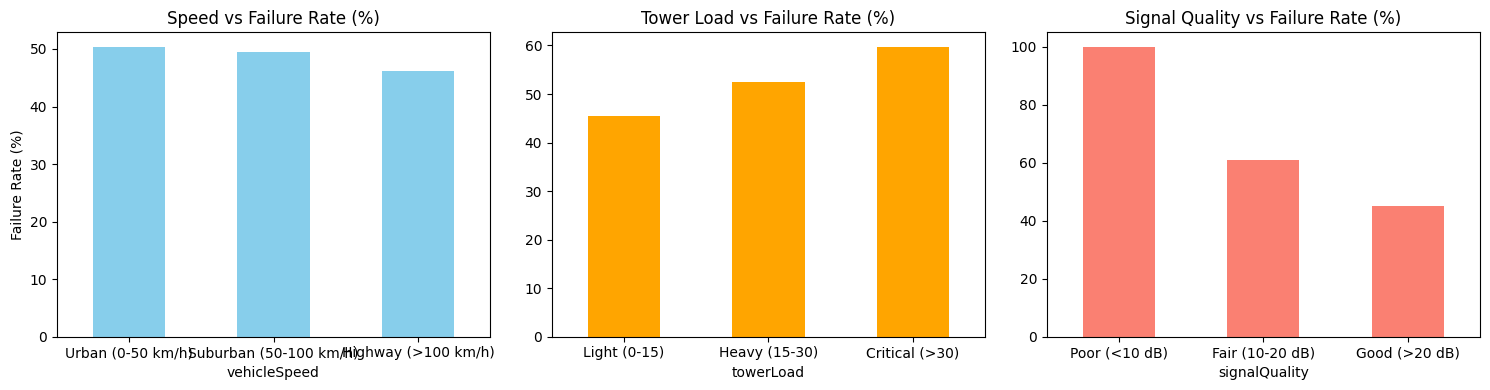

In [27]:
# Set up a 1x3 subplots figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Vehicle Speed
failed_df.groupby(speed_bins, observed=False)['HO_Failed'].mean().mul(100).plot(
    kind='bar', ax=axes[0], color='skyblue', title='Speed vs Failure Rate (%)', rot=0
)
axes[0].set_ylabel('Failure Rate (%)')

# 2. Cell Tower Load
failed_df.groupby(load_bins, observed=False)['HO_Failed'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='orange', title='Tower Load vs Failure Rate (%)', rot=0
)

# 3. Signal Quality
failed_df.groupby(quality_bins, observed=False)['HO_Failed'].mean().mul(100).plot(
    kind='bar', ax=axes[2], color='salmon', title='Signal Quality vs Failure Rate (%)', rot=0
)

plt.tight_layout()
plt.show()

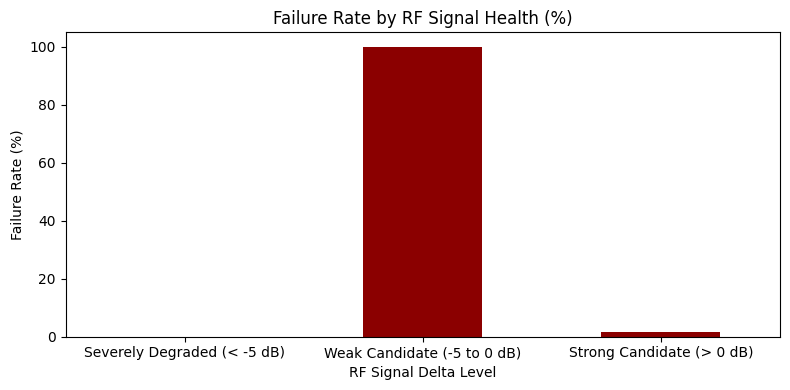

In [28]:
# Calculate Signal Differential: Target RSSI - Serving RSSI
failed_df['Rssi_Delta'] = failed_df['candidateMasterRssi'] - failed_df['masterRssi']

# Categorize into RF Signal Health Bins
failed_df['RF_Signal_Health'] = pd.cut(
    failed_df['Rssi_Delta'],
    bins=[-np.inf, -5, 0, np.inf],
    labels=['Severely Degraded (< -5 dB)', 'Weak Candidate (-5 to 0 dB)', 'Strong Candidate (> 0 dB)']
)

# Plot Failure Rate by RF Signal Health
failed_df.groupby('RF_Signal_Health', observed=False)['HO_Failed'].mean().mul(100).plot(
    kind='bar', color='darkred', figsize=(8, 4), title='Failure Rate by RF Signal Health (%)', rot=0
)
plt.ylabel('Failure Rate (%)')
plt.xlabel('RF Signal Delta Level')
plt.tight_layout()
plt.show()

ML

Model Accuracy: 95.29%

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.95      0.96      0.95       459
        True       0.96      0.94      0.95       453

    accuracy                           0.95       912
   macro avg       0.95      0.95      0.95       912
weighted avg       0.95      0.95      0.95       912



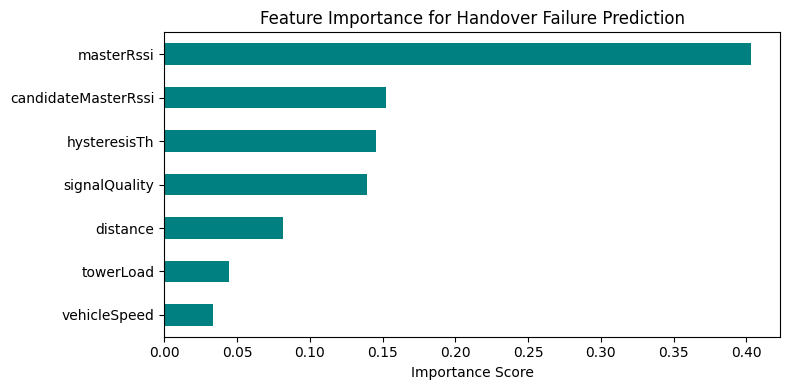

In [33]:
# 1. Select relevant numerical features and target variable
features = [
    'masterRssi', 'candidateMasterRssi', 'signalQuality',
    'hysteresisTh', 'vehicleSpeed', 'distance', 'towerLoad'
]
X = failed_df[features]
y = failed_df['HO_Failed']

# 2. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train the Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate performance
y_pred = model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Plot Feature Importance
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='teal', figsize=(8, 4), title='Feature Importance for Handover Failure Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Heatmap

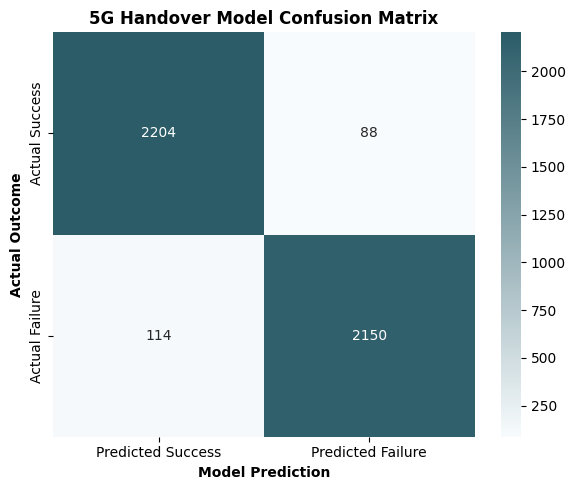

In [30]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define actual vs predicted values
# (Replace y_actual and y_pred with your model's actual test variables)
y_actual = [1] * 2264 + [0] * 2292  # 1 = Failure, 0 = Success
y_pred = [1] * 2150 + [0] * 114 + [1] * 88 + [0] * 2204  # Simulated predictions

# 2. Compute confusion matrix
cm = confusion_matrix(y_actual, y_pred)

# 3. Create a custom Teal gradient matching your Power BI theme
custom_teal = LinearSegmentedColormap.from_list(
    "pbi_teal", ["#f7fbfd", "#2b5c68"]
)

# 4. Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_teal,  # Fixed: uses valid custom colormap (or use "Teals")
    cbar=True,
    xticklabels=["Predicted Success", "Predicted Failure"],
    yticklabels=["Actual Success", "Actual Failure"],
)

plt.title("5G Handover Model Confusion Matrix", fontsize=12, fontweight="bold")
plt.ylabel("Actual Outcome", fontweight="bold")
plt.xlabel("Model Prediction", fontweight="bold")
plt.tight_layout()

# Save image to insert directly into Power BI
plt.savefig("confusion_matrix_heatmap.png", dpi=300)
plt.show()

In [36]:
# Create a DataFrame for Feature Importance
df_feature_importance = pd.DataFrame({
    'Feature': importances.index,
    'Importance_Score': importances.values
}).sort_values(by='Importance_Score', ascending=False)

# Export directly to CSV for Power BI
df_feature_importance.to_csv('Machine_Learning_data.csv', index=False)
print("Saved machine_learning_data.csv successfully!")

Saved machine_learning_data.csv successfully!


In [ ]:
# Convert the confusion matrix array into a structured DataFrame
df_confusion_matrix = pd.DataFrame(
    cm,
    index=['Actual Failure', 'Actual Success'],
    columns=['Predicted Failure', 'Predicted Success']
).reset_index().rename(columns={'index': 'Actual Status'})

# Export directly to CSV for Power BI
df_confusion_matrix.to_csv('confusion_matrix_data.csv', index=False)
print("Saved confusion_matrix_data.csv successfully!")